<!-- Cell purpose: Introduce the SHG embryonated egg analysis notebook. -->

# SHG Embryonated Egg Analysis (`analysis_SHG_embryonated.ipynb`)

This notebook analyzes embryonated eggs for SHG treatment groups and pooled controls.

Rules applied:
- Main readout: `dt_motion_stop_h = t_motion_stop_h - t_start_h`
- Still moving at end-of-footage: `t_motion_stop_h = NA` and `death_mode = NA`
- Exclude from all analyses: `flags` contains `no_larvae`
- In-egg stop cohort: exclude `death_after_hatch`
- Max observation time: 700 h




In [1]:
# Import libraries and configure notebook settings

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
except Exception as exc:
    KaplanMeierFitter = None
    logrank_test = None
    multivariate_logrank_test = None
    print(f"lifelines import failed: {exc}. Step 7 / 8C requires `pip install lifelines`.")

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/02_master_embryonated.csv"

TREATMENT_GROUP_ORDER = [
    "400-SHG-10mW-5s",
    "400-SHG-10mW-10s",
    "400-SHG-15mW-5s",
    "400-SHG-15mW-10s",
    "400-SHG-20mW-10s",
    "400-SHG-30mW-5s",
    "400-SHG-30mW-10s",
    "400-SHG-40mW-5s",
    "400-SHG-40mW-10s",
    "400-SHG-40mW-30s",
]

CONTROL_LABELS = [
    "400-SHG-40mW-control",
    "800-control-330mW",
    "400-SHG-20mW-control",
]

GROUP_TO_LABELS = {
    "Control (pooled)": CONTROL_LABELS,
    **{label: [label] for label in TREATMENT_GROUP_ORDER},
}

ALL_GROUP_ORDER = ["Control (pooled)", *TREATMENT_GROUP_ORDER]
DEATH_MODES = ["apoptotic_like", "necrotic_like", "uncertain"]
DEATH_MODE_DISPLAY = {
    "apoptotic_like": "Vacuolated (apoptosis-like)",
    "necrotic_like": "Lytic (necrosis-like)",
    "uncertain": "Indeterminate/hatched",
    "uncertein": "Indeterminate/hatched",
}
TERMINAL_PHENOTYPE_LABEL = "Terminal phenotype"
DEATH_MODE_DISPLAY_ORDER = [DEATH_MODE_DISPLAY[m] for m in DEATH_MODES]
DEATH_MODE_PALETTE = {
    "Vacuolated (apoptosis-like)": "#59a14f",
    "Lytic (necrosis-like)": "#e15759",
    "Indeterminate/hatched": "#4e79a7",
}
MAX_FOOTAGE_H = 700.0

OUT_BASE = Path("400nm/embryonated")
PLOTS_DIR = OUT_BASE / "plots"
TABLES_DIR = OUT_BASE / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)




In [2]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"", "na", "none"}:
        return np.nan
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


def normalize_flags(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    if raw == "" or raw.lower() in {"na", "none"}:
        return np.nan

    parts = [to_snake_or_nan(part) for part in raw.split(";")]
    parts = [p for p in parts if pd.notna(p)]
    if not parts:
        return np.nan
    return ";".join(parts)


def has_flag(series: pd.Series, token: str) -> pd.Series:
    token_norm = to_snake_or_nan(token)
    if pd.isna(token_norm):
        return pd.Series(False, index=series.index)
    pattern = rf"(?:^|;){re.escape(token_norm)}(?:$|;)"
    return series.fillna("").str.contains(pattern, regex=True)


def pct(n: int, d: int) -> float:
    return (100.0 * n / d) if d else np.nan


def median_iqr(series: pd.Series):
    vals = series.dropna().astype(float)
    if vals.empty:
        return np.nan, np.nan, np.nan
    return float(vals.median()), float(vals.quantile(0.25)), float(vals.quantile(0.75))



In [3]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

required_cols = [
    "egg_uid",
    "exp_label",
    "start_date",
    "control",
    "t_start_h",
    "t_motion_stop_h",
    "death_mode",
    "flags",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "death_mode"]:
    if col in df.columns:
        df[col] = df[col].map(to_snake_or_nan)

if "death_mode" in df.columns:
    df["death_mode"] = df["death_mode"].replace({"uncertein": "uncertain"})

if "flags" in df.columns:
    df["flags"] = df["flags"].map(normalize_flags)

df["exp_label_norm"] = df["exp_label"].map(to_snake_or_nan)

for col in [
    "control",
    "wl_nm",
    "power_mW",
    "irradiance_mW_cm2",
    "exposure_s",
    "fluence_J_cm2",
    "t_start_h",
    "t_motion_stop_h",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["dt_motion_stop_h"] = df["t_motion_stop_h"] - df["t_start_h"]

group_frames = []
for group_name, labels in GROUP_TO_LABELS.items():
    label_norm = {to_snake_or_nan(x) for x in labels}
    mask = df["exp_label_norm"].isin(label_norm)
    if group_name == "Control (pooled)":
        mask &= (df["control"] == 1)

    g = df.loc[mask].copy()
    g["analysis_group"] = group_name
    group_frames.append(g)

analysis_df = pd.concat(group_frames, ignore_index=True)
analysis_df["analysis_group"] = pd.Categorical(
    analysis_df["analysis_group"], categories=ALL_GROUP_ORDER, ordered=True
)

analysis_df["flag_no_larvae"] = has_flag(analysis_df["flags"], "no_larvae")
analysis_df["flag_death_after_hatch"] = has_flag(analysis_df["flags"], "death_after_hatch")
analysis_df["flag_exit_egg"] = has_flag(analysis_df["flags"], "exit_egg")
analysis_df["flag_terminal_twitching"] = has_flag(analysis_df["flags"], "terminal_twitching")

analysis_df["is_analyzed"] = ~analysis_df["flag_no_larvae"]
analysis_df["is_continued_motion"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].isna()
    & analysis_df["death_mode"].isna()
)
analysis_df["is_stopped_in_egg"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].notna()
    & (~analysis_df["flag_death_after_hatch"])
    & (analysis_df["t_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["is_event_survival"] = (
    analysis_df["is_analyzed"]
    & analysis_df["dt_motion_stop_h"].notna()
    & (analysis_df["dt_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["duration_survival_h"] = np.where(
    analysis_df["is_event_survival"], analysis_df["dt_motion_stop_h"], MAX_FOOTAGE_H
)
analysis_df["duration_survival_h"] = analysis_df["duration_survival_h"].astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

print(f"Loaded: {csv_file}")
print(f"Rows in full master table: {len(df)}")
print(f"Rows in analysis subset (control + SHG groups): {len(analysis_df)}")

group_counts_raw = (
    analysis_df.groupby("analysis_group", observed=False)
    .size()
    .rename("n_raw")
    .reset_index()
)

group_counts_analyzed = (
    analysis_df[analysis_df["is_analyzed"]]
    .groupby("analysis_group", observed=False)
    .size()
    .rename("n_after_no_larvae_exclusion")
    .reset_index()
)

display(group_counts_raw.merge(group_counts_analyzed, on="analysis_group", how="left"))
analysis_preview_df = analysis_df[
    [
        "egg_uid",
        "analysis_group",
        "exp_label",
        "t_start_h",
        "t_motion_stop_h",
        "dt_motion_stop_h",
        "death_mode",
        "flags",
        "is_analyzed",
    ]
].copy()
analysis_preview_df[TERMINAL_PHENOTYPE_LABEL] = (
    analysis_preview_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(analysis_preview_df["death_mode"])
)
display(analysis_preview_df.drop(columns=["death_mode"]).head())




Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/02_master_embryonated.csv
Rows in full master table: 811
Rows in analysis subset (control + SHG groups): 475


,analysis_group,n_raw,n_after_no_larvae_exclusion
0,Control (pooled),97,97
1,400-SHG-10mW-5s,36,36
2,400-SHG-10mW-10s,36,36
3,400-SHG-15mW-5s,38,38
4,400-SHG-15mW-10s,38,38
5,400-SHG-20mW-10s,37,37
6,400-SHG-30mW-5s,39,39
7,400-SHG-30mW-10s,40,40
8,400-SHG-40mW-5s,36,36
9,400-SHG-40mW-10s,38,38


,egg_uid,analysis_group,exp_label,t_start_h,t_motion_stop_h,dt_motion_stop_h,flags,is_analyzed,Terminal phenotype
0,115,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
1,116,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
2,117,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
3,118,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN
4,119,Control (pooled),400-SHG-40mW-control,41.5,NaN,NaN,NaN,True,NaN


In [4]:
# Data QC and overview table

qc_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[analysis_df["analysis_group"] == group].copy()
    sub_an = sub.loc[sub["is_analyzed"]].copy()

    n_total = int(len(sub))
    n_excl_no_larvae = int(sub["flag_no_larvae"].sum())
    n_analyzed = int(len(sub_an))

    row = {
        "group": group,
        "n_total": n_total,
        "n_excluded_no_larvae": n_excl_no_larvae,
        "pct_excluded_no_larvae": round(pct(n_excl_no_larvae, n_total), 1),
        "n_analyzed": n_analyzed,
    }

    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        row[f"n_{mode}"] = n_mode
        row[f"pct_{mode}"] = round(pct(n_mode, n_analyzed), 1)

    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        row[f"n_flag_{flag}"] = n_flag
        row[f"pct_flag_{flag}"] = round(pct(n_flag, n_analyzed), 1)

    qc_rows.append(row)

qc_overview_df = pd.DataFrame(qc_rows)
qc_overview_display_df = qc_overview_df.rename(
    columns={
        **{f"n_{mode}": f"n_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
        **{f"pct_{mode}": f"pct_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
    }
)
display(qc_overview_display_df)

qc_death_mode_long = []
for group in ALL_GROUP_ORDER:
    sub_an = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_analyzed = int(len(sub_an))
    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        qc_death_mode_long.append(
            {
                "group": group,
                "death_mode": mode,
                "n": n_mode,
                "pct": round(pct(n_mode, n_analyzed), 1),
            }
        )
qc_death_mode_long_df = pd.DataFrame(qc_death_mode_long)
qc_death_mode_long_df["death_mode"] = (
    qc_death_mode_long_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(qc_death_mode_long_df["death_mode"])
)
qc_death_mode_long_df = qc_death_mode_long_df.rename(columns={"death_mode": TERMINAL_PHENOTYPE_LABEL})
display(qc_death_mode_long_df)

qc_flags_long = []
for group in ALL_GROUP_ORDER:
    sub_an = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_analyzed = int(len(sub_an))
    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        qc_flags_long.append(
            {
                "group": group,
                "flag": flag,
                "n": n_flag,
                "pct": round(pct(n_flag, n_analyzed), 1),
            }
        )
qc_flags_long_df = pd.DataFrame(qc_flags_long)
display(qc_flags_long_df)

qc_overview_display_df.to_csv(TABLES_DIR / "shg_embryonated_qc_overview.csv", index=False)
qc_death_mode_long_df.to_csv(TABLES_DIR / "shg_embryonated_qc_death_mode_long.csv", index=False)
qc_flags_long_df.to_csv(TABLES_DIR / "shg_embryonated_qc_flags_long.csv", index=False)

print(f"Saved QC tables to: {TABLES_DIR.resolve()}")



,group,n_total,n_excluded_no_larvae,pct_excluded_no_larvae,n_analyzed,n_Vacuolated (apoptosis-like),pct_Vacuolated (apoptosis-like),n_Lytic (necrosis-like),pct_Lytic (necrosis-like),n_Indeterminate/hatched,pct_Indeterminate/hatched,n_flag_death_after_hatch,pct_flag_death_after_hatch,n_flag_exit_egg,pct_flag_exit_egg,n_flag_terminal_twitching,pct_flag_terminal_twitching
0,Control (pooled),97,0,0.0,97,0,0.0,3,3.1,12,12.4,9,9.3,1,1.0,0,0.0
1,400-SHG-10mW-5s,36,0,0.0,36,0,0.0,18,50.0,11,30.6,11,30.6,18,50.0,0,0.0
2,400-SHG-10mW-10s,36,0,0.0,36,2,5.6,21,58.3,8,22.2,8,22.2,23,63.9,0,0.0
3,400-SHG-15mW-5s,38,0,0.0,38,34,89.5,1,2.6,2,5.3,1,2.6,28,73.7,0,0.0
4,400-SHG-15mW-10s,38,0,0.0,38,38,100.0,0,0.0,0,0.0,0,0.0,35,92.1,0,0.0
5,400-SHG-20mW-10s,37,0,0.0,37,37,100.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
6,400-SHG-30mW-5s,39,0,0.0,39,39,100.0,0,0.0,0,0.0,0,0.0,1,2.6,0,0.0
7,400-SHG-30mW-10s,40,0,0.0,40,40,100.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
8,400-SHG-40mW-5s,36,0,0.0,36,35,97.2,1,2.8,0,0.0,0,0.0,0,0.0,0,0.0
9,400-SHG-40mW-10s,38,0,0.0,38,38,100.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


,group,Terminal phenotype,n,pct
0,Control (pooled),Vacuolated (apoptosis-like),0,0.0
1,Control (pooled),Lytic (necrosis-like),3,3.1
2,Control (pooled),Indeterminate/hatched,12,12.4
3,400-SHG-10mW-5s,Vacuolated (apoptosis-like),0,0.0
4,400-SHG-10mW-5s,Lytic (necrosis-like),18,50.0
5,400-SHG-10mW-5s,Indeterminate/hatched,11,30.6
6,400-SHG-10mW-10s,Vacuolated (apoptosis-like),2,5.6
7,400-SHG-10mW-10s,Lytic (necrosis-like),21,58.3
8,400-SHG-10mW-10s,Indeterminate/hatched,8,22.2
9,400-SHG-15mW-5s,Vacuolated (apoptosis-like),34,89.5


,group,flag,n,pct
0,Control (pooled),death_after_hatch,9,9.3
1,Control (pooled),exit_egg,1,1.0
2,Control (pooled),terminal_twitching,0,0.0
3,400-SHG-10mW-5s,death_after_hatch,11,30.6
4,400-SHG-10mW-5s,exit_egg,18,50.0
5,400-SHG-10mW-5s,terminal_twitching,0,0.0
6,400-SHG-10mW-10s,death_after_hatch,8,22.2
7,400-SHG-10mW-10s,exit_egg,23,63.9
8,400-SHG-10mW-10s,terminal_twitching,0,0.0
9,400-SHG-15mW-5s,death_after_hatch,1,2.6


Saved QC tables to: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/tables


In [5]:
# Motion cessation analysis (each SHG treatment separately)

motion_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()

    n_total = int(len(sub))
    n_cont = int(sub["is_continued_motion"].sum())

    sub_stopped_in_egg = sub.loc[
        sub["is_stopped_in_egg"] & sub["dt_motion_stop_h"].notna(),
        "dt_motion_stop_h",
    ]
    n_stop_in_egg = int(len(sub_stopped_in_egg))
    med, q1, q3 = median_iqr(sub_stopped_in_egg)

    motion_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_continued_motion": n_cont,
            "pct_continued_motion": round(pct(n_cont, n_total), 1),
            "n_stopped_in_egg": n_stop_in_egg,
            "pct_stopped_in_egg": round(pct(n_stop_in_egg, n_total), 1),
            "median_dt_motion_stop_h": round(med, 2) if pd.notna(med) else np.nan,
            "q1_dt_motion_stop_h": round(q1, 2) if pd.notna(q1) else np.nan,
            "q3_dt_motion_stop_h": round(q3, 2) if pd.notna(q3) else np.nan,
            "iqr_dt_motion_stop_h": (
                f"{q1:.2f} to {q3:.2f}" if pd.notna(q1) and pd.notna(q3) else np.nan
            ),
        }
    )

motion_summary_df = pd.DataFrame(motion_rows)
display(motion_summary_df)
motion_summary_df.to_csv(TABLES_DIR / "shg_embryonated_motion_cessation_summary.csv", index=False)



,treatment,n_total_excluding_no_larvae,n_continued_motion,pct_continued_motion,n_stopped_in_egg,pct_stopped_in_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,400-SHG-10mW-5s,36,7,19.4,18,50.0,356.7,208.2,509.20,208.20 to 509.20
1,400-SHG-10mW-10s,36,5,13.9,23,63.9,264.8,168.8,352.80,168.80 to 352.80
2,400-SHG-15mW-5s,38,1,2.6,36,94.7,187.0,157.5,308.75,157.50 to 308.75
3,400-SHG-15mW-10s,38,0,0.0,38,100.0,11.7,0.0,173.20,0.00 to 173.20
4,400-SHG-20mW-10s,37,0,0.0,37,100.0,0.0,0.0,2.00,0.00 to 2.00
5,400-SHG-30mW-5s,39,0,0.0,39,100.0,0.0,0.0,0.00,0.00 to 0.00
6,400-SHG-30mW-10s,40,0,0.0,40,100.0,0.0,0.0,0.00,0.00 to 0.00
7,400-SHG-40mW-5s,36,0,0.0,36,100.0,0.0,0.0,0.00,0.00 to 0.00
8,400-SHG-40mW-10s,38,0,0.0,38,100.0,0.0,0.0,0.00,0.00 to 0.00
9,400-SHG-40mW-30s,40,0,0.0,40,100.0,0.0,0.0,0.00,0.00 to 0.00


In [6]:
# Comparison table: percentage still moving at 700h

comparison_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_still = int(sub["is_continued_motion"].sum())
    comparison_rows.append(
        {
            "Treatment": group,
            "n_total": n_total,
            "n_still_moving": n_still,
            "% still moving": round(pct(n_still, n_total), 1),
        }
    )

still_moving_df = pd.DataFrame(comparison_rows)
display(still_moving_df)
still_moving_df.to_csv(TABLES_DIR / "shg_embryonated_still_moving_comparison.csv", index=False)

tx_only = still_moving_df[still_moving_df["Treatment"].isin(TREATMENT_GROUP_ORDER)].copy()
most_effective = tx_only.loc[tx_only["% still moving"].idxmin()]
least_effective = tx_only.loc[tx_only["% still moving"].idxmax()]

print(
    f"Interpretation note: {most_effective['Treatment']} has the lowest still-moving fraction "
    f"({most_effective['% still moving']}%), while {least_effective['Treatment']} has the highest "
    f"({least_effective['% still moving']}%)."
)



,Treatment,n_total,n_still_moving,% still moving
0,Control (pooled),97,82,84.5
1,400-SHG-10mW-5s,36,7,19.4
2,400-SHG-10mW-10s,36,5,13.9
3,400-SHG-15mW-5s,38,1,2.6
4,400-SHG-15mW-10s,38,0,0.0
5,400-SHG-20mW-10s,37,0,0.0
6,400-SHG-30mW-5s,39,0,0.0
7,400-SHG-30mW-10s,40,0,0.0
8,400-SHG-40mW-5s,36,0,0.0
9,400-SHG-40mW-10s,38,0,0.0


Interpretation note: 400-SHG-15mW-10s has the lowest still-moving fraction (0.0%), while 400-SHG-10mW-5s has the highest (19.4%).


Figure caption: Terminal phenotype composition across analyzed SHG embryonated treatment groups. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels report absolute counts as n/total analyzed for each treatment.


,treatment,n_total_analyzed,n,pct,Terminal phenotype
0,400-SHG-10mW-5s,36,0,0.0,Vacuolated (apoptosis-like)
1,400-SHG-10mW-5s,36,18,50.0,Lytic (necrosis-like)
2,400-SHG-10mW-5s,36,11,30.6,Indeterminate/hatched
3,400-SHG-10mW-10s,36,2,5.6,Vacuolated (apoptosis-like)
4,400-SHG-10mW-10s,36,21,58.3,Lytic (necrosis-like)
5,400-SHG-10mW-10s,36,8,22.2,Indeterminate/hatched
6,400-SHG-15mW-5s,38,34,89.5,Vacuolated (apoptosis-like)
7,400-SHG-15mW-5s,38,1,2.6,Lytic (necrosis-like)
8,400-SHG-15mW-5s,38,2,5.3,Indeterminate/hatched
9,400-SHG-15mW-10s,38,38,100.0,Vacuolated (apoptosis-like)


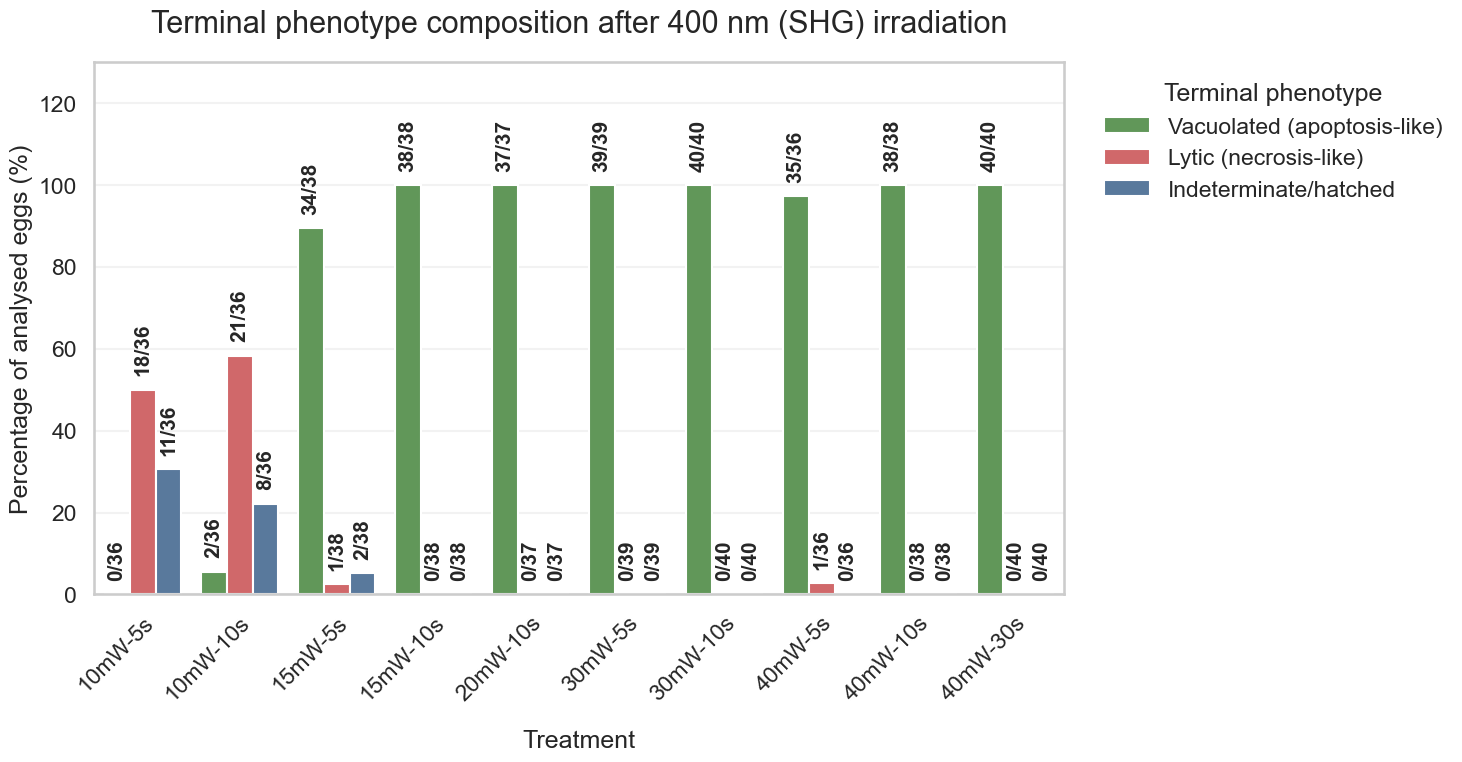

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/plots/shg_embryonated_death_mode_distribution.png


In [7]:
# Plot terminal phenotype distributions by treatment

print('Figure caption: Terminal phenotype composition across analyzed SHG embryonated treatment groups. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels report absolute counts as n/total analyzed for each treatment.')

death_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    for mode in DEATH_MODES:
        n_mode = int((sub["death_mode"] == mode).sum())
        death_rows.append(
            {
                "treatment": group,
                "death_mode": mode,
                "n_total_analyzed": n_total,
                "n": n_mode,
                "pct": round(pct(n_mode, n_total), 1),
            }
        )

death_mode_dist_df = pd.DataFrame(death_rows)
death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] = (
    death_mode_dist_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(death_mode_dist_df["death_mode"])
)
display(death_mode_dist_df.drop(columns=["death_mode"]))

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(
    data=death_mode_dist_df,
    x="treatment",
    y="pct",
    hue=TERMINAL_PHENOTYPE_LABEL,
    hue_order=DEATH_MODE_DISPLAY_ORDER,
    order=TREATMENT_GROUP_ORDER,
    palette=DEATH_MODE_PALETTE,
    ax=ax,
)
ax.set_xlabel("Treatment", labelpad=18)
ax.set_ylabel("Percentage of analysed eggs (%)")
ax.set_title("Terminal phenotype composition after 400 nm (SHG) irradiation", y=1.04, fontsize=22)
ymax = death_mode_dist_df["pct"].dropna().max() if len(death_mode_dist_df) else 100
ax.set_ylim(0, max(130, (float(ymax) + 10) if pd.notna(ymax) else 130))
ax.legend(title=TERMINAL_PHENOTYPE_LABEL, frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.25)
shg_xlabels = [t.replace("400-SHG-", "") for t in TREATMENT_GROUP_ORDER]
ax.set_xticks(range(len(TREATMENT_GROUP_ORDER)))
ax.set_xticklabels(shg_xlabels, rotation=45, ha="right", rotation_mode="anchor")
for container, mode_label in zip(ax.containers, DEATH_MODE_DISPLAY_ORDER):
    labels = []
    for treatment in TREATMENT_GROUP_ORDER:
        row = death_mode_dist_df[
            (death_mode_dist_df["treatment"] == treatment)
            & (death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] == mode_label)
        ]
        if row.empty:
            labels.append("")
            continue
        n_total = int(row["n_total_analyzed"].iloc[0])
        n_mode = int(row["n"].iloc[0])
        labels.append(f"{n_mode}/{n_total}" if n_total > 0 else "")
    bar_texts = ax.bar_label(container, labels=labels, padding=10, fontsize=15, fontweight="bold", rotation=90)
    for txt in bar_texts:
        txt.set_clip_on(False)
plt.tight_layout()

out_png = PLOTS_DIR / "shg_embryonated_death_mode_distribution.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png.resolve()}")

death_mode_dist_df.drop(columns=["death_mode"]).to_csv(TABLES_DIR / "shg_embryonated_death_mode_distribution.csv", index=False)




In [8]:
# Death-after-hatch events per treatment

dah_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_dah = int(sub["flag_death_after_hatch"].sum())
    dah_rows.append(
        {
            "treatment": group,
            "n_total_excluding_no_larvae": n_total,
            "n_death_after_hatch": n_dah,
            "pct_death_after_hatch": round(pct(n_dah, n_total), 1),
        }
    )

death_after_hatch_df = pd.DataFrame(dah_rows)
display(death_after_hatch_df)

death_after_hatch_df.to_csv(TABLES_DIR / "shg_embryonated_death_after_hatch_summary.csv", index=False)



,treatment,n_total_excluding_no_larvae,n_death_after_hatch,pct_death_after_hatch
0,400-SHG-10mW-5s,36,11,30.6
1,400-SHG-10mW-10s,36,8,22.2
2,400-SHG-15mW-5s,38,1,2.6
3,400-SHG-15mW-10s,38,0,0.0
4,400-SHG-20mW-10s,37,0,0.0
5,400-SHG-30mW-5s,39,0,0.0
6,400-SHG-30mW-10s,40,0,0.0
7,400-SHG-40mW-5s,36,0,0.0
8,400-SHG-40mW-10s,38,0,0.0
9,400-SHG-40mW-30s,40,0,0.0


Figure caption: Distribution of in-egg motion-stop timing (`dt_motion_stop_h`) across included SHG treatments. Only in-egg stop events are plotted; treatments flagged as non-motile at footage start and groups with insufficient observations are excluded per notebook rules. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), and jittered points show individual eggs.


,analysis_group,n_points
0,400-SHG-10mW-5s,18
1,400-SHG-10mW-10s,23
2,400-SHG-15mW-5s,36
3,400-SHG-15mW-10s,38
4,400-SHG-20mW-10s,37
5,400-SHG-30mW-5s,39
6,400-SHG-30mW-10s,40
7,400-SHG-40mW-5s,36
8,400-SHG-40mW-10s,38
9,400-SHG-40mW-30s,40


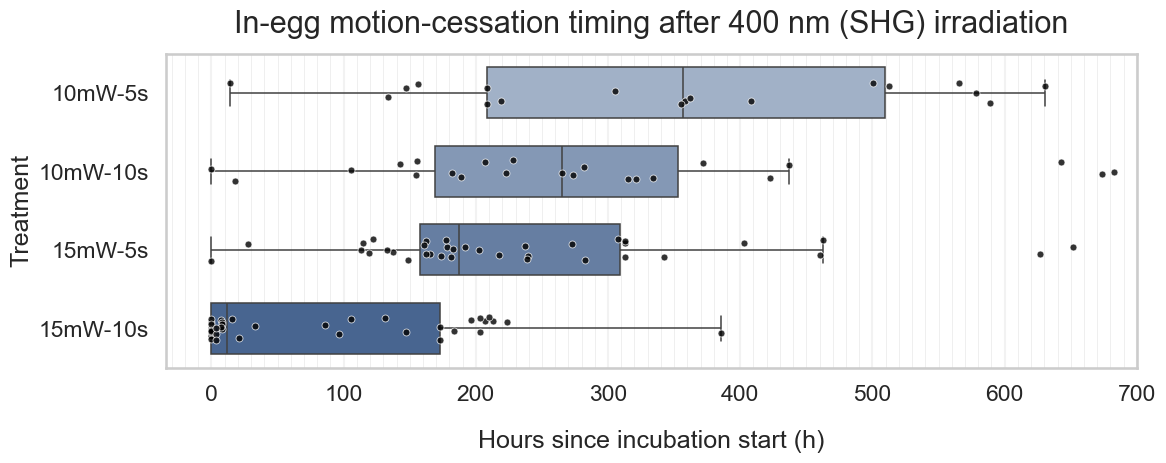

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/plots/shg_embryonated_dt_motion_stop_boxplot.png
Note: The following treatments are not represented in this boxplot because larvae were already non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already non-motile), so these are not in-footage motion-cessation events: 400-SHG-20mW-10s (n=37), 400-SHG-30mW-5s (n=39), 400-SHG-30mW-10s (n=40), 400-SHG-40mW-5s (n=36), 400-SHG-40mW-10s (n=38), 400-SHG-40mW-30s (n=40).


In [9]:
# Horizontal boxplot + stripplot overlay: in-egg motion stop times (SHG treatments only)

print('Figure caption: Distribution of in-egg motion-stop timing (`dt_motion_stop_h`) across included SHG treatments. Only in-egg stop events are plotted; treatments flagged as non-motile at footage start and groups with insufficient observations are excluded per notebook rules. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), and jittered points show individual eggs.')

boxplot_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(TREATMENT_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["egg_uid", "analysis_group", "dt_motion_stop_h", "flags", "death_mode"],
].copy()

point_counts = (
    boxplot_df.groupby("analysis_group", observed=False)
    .size()
    .reindex(TREATMENT_GROUP_ORDER, fill_value=0)
    .rename("n_points")
    .reset_index()
)
display(point_counts)

EXCLUDE_NON_MOTILE_AT_START = {
    "400-SHG-40mW-30s",
    "400-SHG-40mW-10s",
    "400-SHG-40mW-5s",
    "400-SHG-30mW-10s",
    "400-SHG-30mW-5s",
    "400-SHG-20mW-10s",
}

MIN_N_FOR_BOX = 2
groups_for_box = (
    point_counts.loc[
        (point_counts["n_points"] >= MIN_N_FOR_BOX)
        & (~point_counts["analysis_group"].isin(EXCLUDE_NON_MOTILE_AT_START)),
        "analysis_group",
    ]
    .astype(str)
    .tolist()
)

excluded_groups_count = (
    point_counts.loc[point_counts["n_points"] < MIN_N_FOR_BOX, ["analysis_group", "n_points"]]
    .copy()
)
excluded_groups_non_motile = (
    point_counts.loc[point_counts["analysis_group"].isin(EXCLUDE_NON_MOTILE_AT_START), ["analysis_group", "n_points"]]
    .copy()
)

if not groups_for_box:
    raise ValueError("No treatment qualifies for this boxplot after applying exclusion rules.")

plot_df = boxplot_df[boxplot_df["analysis_group"].astype(str).isin(groups_for_box)].copy()

palette_vals = sns.blend_palette(["#9bb0cd", "#3c639c"], n_colors=max(len(groups_for_box), 3))
palette = {g: palette_vals[i] for i, g in enumerate(groups_for_box)}

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    order=groups_for_box,
    hue="analysis_group",
    hue_order=groups_for_box,
    palette=palette,
    showfliers=False,
    width=0.65,
    dodge=False,
    linewidth=1.1,
    legend=False,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    order=groups_for_box,
    color="black",
    size=5,
    alpha=0.8,
    linewidth=0.6,
    edgecolor="white",
    jitter=0.15,
    ax=ax,
)

ax.set_xlabel("Hours since incubation start (h)", labelpad=18)
ax.set_ylabel("Treatment")
ax.set_title("In-egg motion-cessation timing after 400 nm (SHG) irradiation", y=1.04, fontsize=22)
shg_ylabels = [g.replace("400-SHG-", "") for g in groups_for_box]
ax.set_yticks(range(len(groups_for_box)))
ax.set_yticklabels(shg_ylabels)
left_pad_h = max(10.0, 0.05 * float(plot_df["dt_motion_stop_h"].max())) if len(plot_df) > 0 else 10.0
ax.set_xlim(-left_pad_h, MAX_FOOTAGE_H)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
plt.tight_layout()

out_png = PLOTS_DIR / "shg_embryonated_dt_motion_stop_boxplot.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

plot_df.to_csv(TABLES_DIR / "shg_embryonated_dt_motion_stop_boxplot_data.csv", index=False)
point_counts.to_csv(TABLES_DIR / "shg_embryonated_dt_motion_stop_boxplot_counts.csv", index=False)
print(f"Saved: {out_png.resolve()}")

if len(excluded_groups_non_motile) > 0:
    excl_txt_non_motile = ", ".join(
        f"{row.analysis_group} (n={int(row.n_points)})"
        for row in excluded_groups_non_motile.itertuples(index=False)
    )
    print(
        "Note: The following treatments are not represented in this boxplot because larvae were "
        "already non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were "
        "already non-motile), so these are not in-footage motion-cessation events: "
        f"{excl_txt_non_motile}."
    )

if len(excluded_groups_count) > 0:
    excl_txt_count = ", ".join(
        f"{row.analysis_group} (n={int(row.n_points)})"
        for row in excluded_groups_count.itertuples(index=False)
        if row.analysis_group not in EXCLUDE_NON_MOTILE_AT_START
    )
    if excl_txt_count:
        print(
            f"Note: Additional treatments excluded due to insufficient in-egg stop observations "
            f"(n<{MIN_N_FOR_BOX}): {excl_txt_count}."
        )




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
In-egg motion-stop timing for SHG-treated embryonated eggs. Each point is one egg with an observed in-egg stop event; `death_after_hatch` rows are excluded from this endpoint. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), with jittered points for all included eggs. Treatments excluded for baseline non-motility at footage start and groups with insufficient sample size are omitted according to SHG-specific boxplot inclusion rules.


Figure caption: Kaplan-Meier curves for continued larval motion in pooled control plus included SHG treatments. Event is observed in-window motion stop (`event_observed=1`), censoring indicates continued motion/no in-window stop (`event_observed=0`), censor marks are shown, and groups excluded for baseline non-motility follow the same rules used for SHG boxplots.


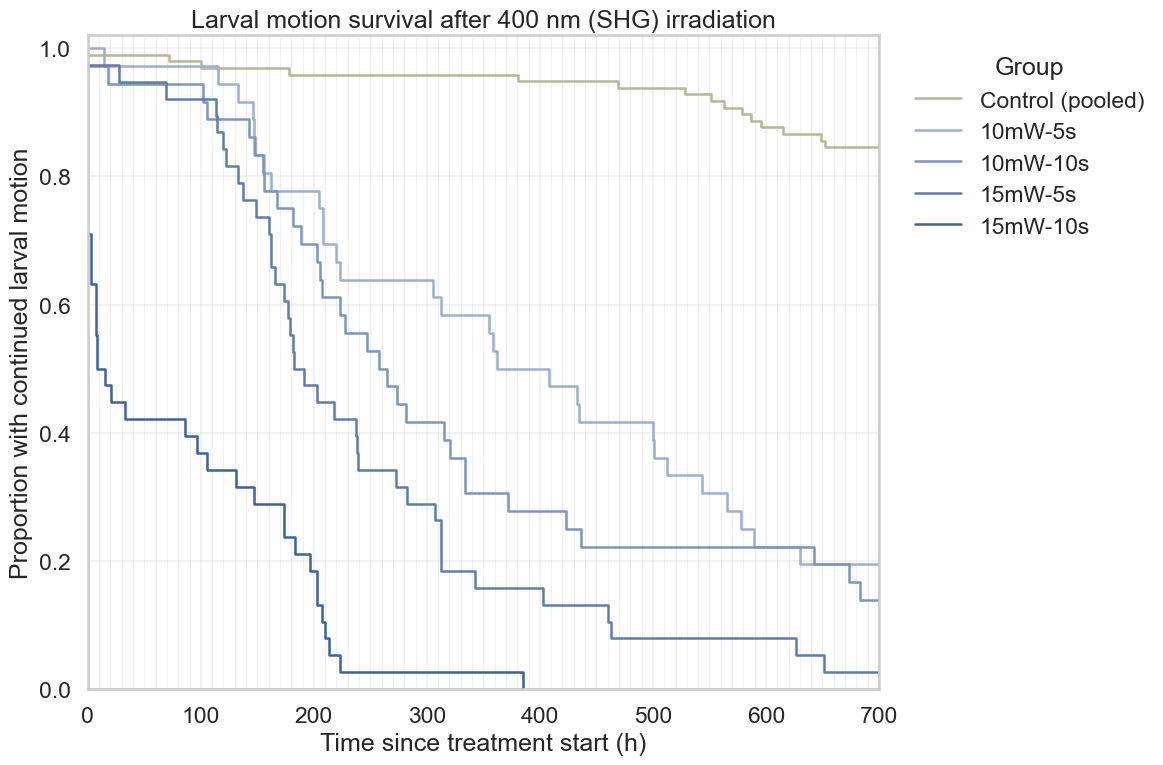

,group,n_total,n_events,n_censored,median_survival_h
0,Control (pooled),97,15,82,inf
1,400-SHG-10mW-5s,36,29,7,362.2
2,400-SHG-10mW-10s,36,31,5,257.8
3,400-SHG-15mW-5s,38,37,1,182.5
4,400-SHG-15mW-10s,38,38,0,8.2


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/plots/shg_embryonated_kaplan_meier_motion_survival.png
Note: The following treatments are not represented in this Kaplan-Meier plot because larvae were already non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already non-motile): 400-SHG-20mW-10s, 400-SHG-30mW-10s, 400-SHG-30mW-5s, 400-SHG-40mW-10s, 400-SHG-40mW-30s, 400-SHG-40mW-5s.


In [10]:
# Kaplan-Meier survival curve (continued larval motion)

print('Figure caption: Kaplan-Meier curves for continued larval motion in pooled control plus included SHG treatments. Event is observed in-window motion stop (`event_observed=1`), censoring indicates continued motion/no in-window stop (`event_observed=0`), censor marks are shown, and groups excluded for baseline non-motility follow the same rules used for SHG boxplots.')

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for Kaplan-Meier and log-rank analyses. Install with: pip install lifelines")

KM_EXCLUDE_NON_MOTILE_AT_START = {
    "400-SHG-40mW-30s",
    "400-SHG-40mW-10s",
    "400-SHG-40mW-5s",
    "400-SHG-30mW-10s",
    "400-SHG-30mW-5s",
    "400-SHG-20mW-10s",
}

groups_for_km = [
    g for g in ALL_GROUP_ORDER
    if (g == "Control (pooled)") or (g not in KM_EXCLUDE_NON_MOTILE_AT_START)
]

survival_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(groups_for_km) & analysis_df["is_analyzed"],
    [
        "egg_uid",
        "analysis_group",
        "duration_survival_h",
        "is_event_survival",
        "dt_motion_stop_h",
        "t_motion_stop_h",
        "death_mode",
        "flags",
    ],
].copy()

survival_df = survival_df.rename(
    columns={
        "duration_survival_h": "duration_h",
        "is_event_survival": "event_observed",
    }
)
survival_df["event_observed"] = survival_df["event_observed"].astype(int)
survival_df["duration_h"] = survival_df["duration_h"].fillna(MAX_FOOTAGE_H).astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

shg_groups_for_km = [g for g in groups_for_km if g != "Control (pooled)"]
palette_vals = sns.blend_palette(["#9bb0cd", "#3c639c"], n_colors=max(len(shg_groups_for_km), 3))
km_colors = {"Control (pooled)": "#b7b695"}
km_colors.update({g: palette_vals[i] for i, g in enumerate(shg_groups_for_km)})

fig, ax = plt.subplots(figsize=(12, 8))
km_rows = []

for group in groups_for_km:
    g = survival_df.loc[survival_df["analysis_group"] == group].copy()
    if g.empty:
        continue

    kmf = KaplanMeierFitter()
    group_label = group.replace("400-SHG-", "") if group.startswith("400-SHG-") else group
    kmf.fit(
        durations=g["duration_h"],
        event_observed=g["event_observed"],
        label=group_label,
    )
    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        color=km_colors.get(group, None),
        show_censors=True,
        censor_styles={"ms": 4, "marker": "|", "mew": 1.0},
        linewidth=1.8,
    )

    med = kmf.median_survival_time_
    km_rows.append(
        {
            "group": group,
            "n_total": int(len(g)),
            "n_events": int(g["event_observed"].sum()),
            "n_censored": int((g["event_observed"] == 0).sum()),
            "median_survival_h": float(med) if np.isfinite(med) else np.inf,
        }
    )

ax.set_xlim(0, MAX_FOOTAGE_H)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Time since treatment start (h)")
ax.set_ylabel("Proportion with continued larval motion")
ax.set_title("Larval motion survival after 400 nm (SHG) irradiation")
ax.grid(alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
ax.legend(title="Group", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

out_png = PLOTS_DIR / "shg_embryonated_kaplan_meier_motion_survival.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

km_summary_df = pd.DataFrame(km_rows)
display(km_summary_df)

km_summary_df.to_csv(TABLES_DIR / "shg_embryonated_km_summary.csv", index=False)
survival_df.to_csv(TABLES_DIR / "shg_embryonated_km_input_data.csv", index=False)
print(f"Saved: {out_png.resolve()}")

excl_txt = ", ".join(sorted(KM_EXCLUDE_NON_MOTILE_AT_START))
print(
    "Note: The following treatments are not represented in this Kaplan-Meier plot because larvae were "
    "already non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already "
    "non-motile): "
    f"{excl_txt}."
)




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Kaplan-Meier curves for continued larval motion in pooled controls plus included SHG treatment groups over 0-700 h. Event definition: observed in-window motion stop (`event_observed = 1`). Censoring definition: continued motion/no in-window stop (`event_observed = 0`), displayed as tick marks. Group inclusion mirrors SHG boxplot exclusions for baseline non-motility, and full-curve differences are assessed in Step 8C using log-rank tests with multiplicity-aware interpretation.


Figure caption: Normality diagnostics for SHG in-egg stop timing among included analysis groups. Shapiro-Wilk statistics are reported when n>=3, and Q-Q panels compare observed and theoretical normal quantiles. Panels with n=1 or n=0 indicate limited/no diagnostic evidence; exclusion rules match SHG boxplot/KM inclusion criteria.
Note: Statistical analysis excludes the same groups as boxplot/KM because larvae were already non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already non-motile): 400-SHG-20mW-10s, 400-SHG-30mW-10s, 400-SHG-30mW-5s, 400-SHG-40mW-10s, 400-SHG-40mW-30s, 400-SHG-40mW-5s.


,group,n_stopped_in_egg,shapiro_W,shapiro_p,normal_by_shapiro_p_gt_0_05,note
0,Control (pooled),6,0.729307,0.012403,False,
1,400-SHG-10mW-5s,18,0.947606,0.388714,True,
2,400-SHG-10mW-10s,23,0.919313,0.064403,True,
3,400-SHG-15mW-5s,36,0.887817,0.001611,False,
4,400-SHG-15mW-10s,38,0.777402,0.000004,False,


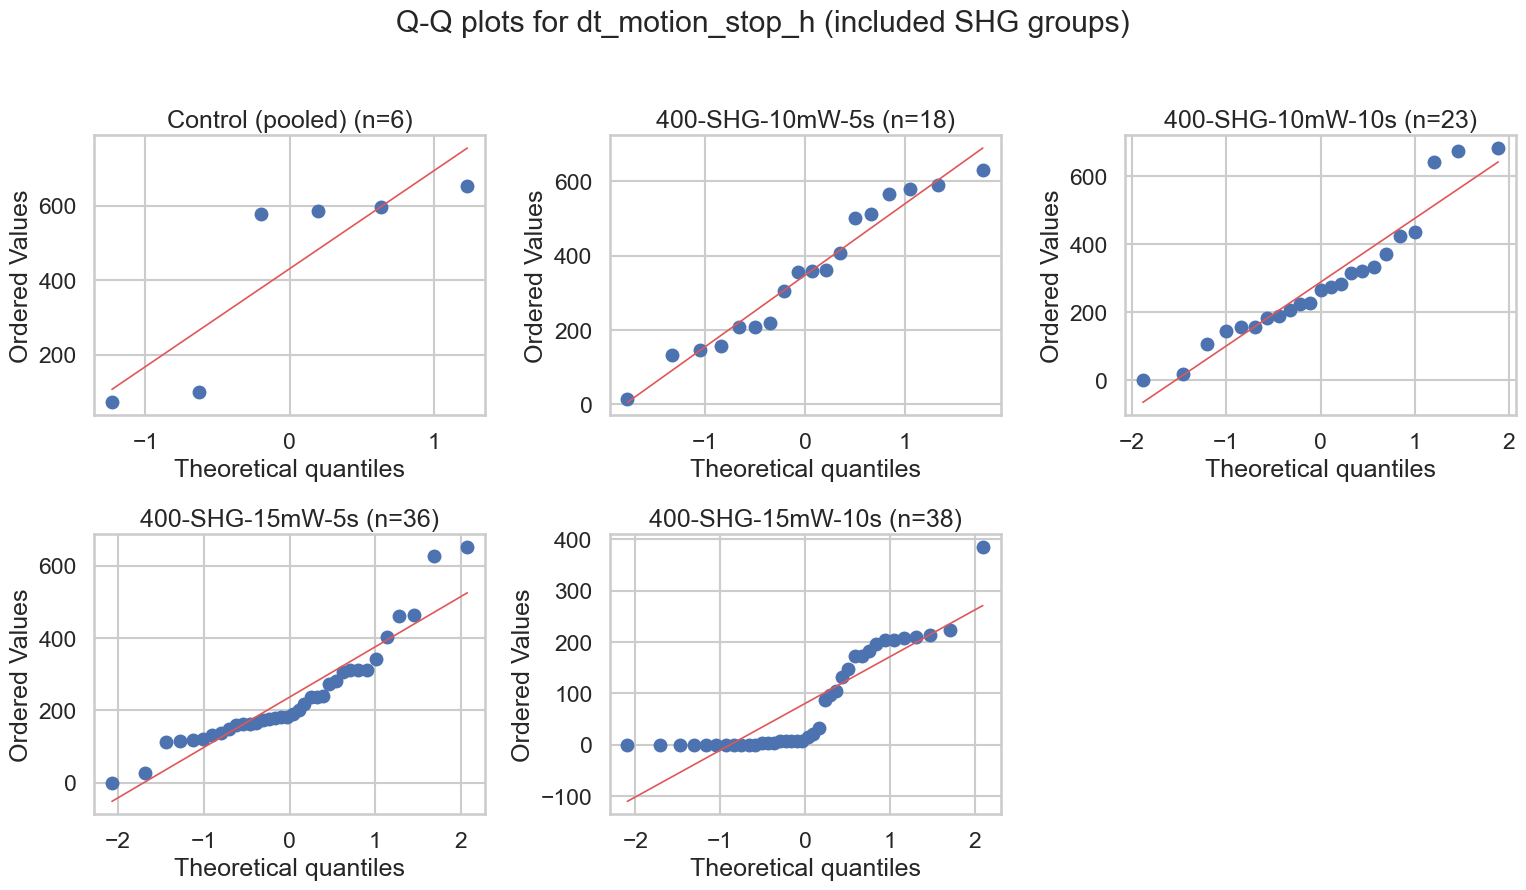

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/plots/shg_embryonated_normality_qqplots.png
Selected comparison family: non_parametric
Reason: at least one included group had n<3 and/or failed Shapiro p<=0.05.


In [11]:
# Normality testing (Shapiro-Wilk) + Q-Q plots

print('Figure caption: Normality diagnostics for SHG in-egg stop timing among included analysis groups. Shapiro-Wilk statistics are reported when n>=3, and Q-Q panels compare observed and theoretical normal quantiles. Panels with n=1 or n=0 indicate limited/no diagnostic evidence; exclusion rules match SHG boxplot/KM inclusion criteria.')

STATS_EXCLUDE_NON_MOTILE_AT_START = {
    "400-SHG-40mW-30s",
    "400-SHG-40mW-10s",
    "400-SHG-40mW-5s",
    "400-SHG-30mW-10s",
    "400-SHG-30mW-5s",
    "400-SHG-20mW-10s",
}

STATS_GROUP_ORDER = [
    g for g in ALL_GROUP_ORDER
    if (g == "Control (pooled)") or (g not in STATS_EXCLUDE_NON_MOTILE_AT_START)
]

excluded_txt = ", ".join(sorted(STATS_EXCLUDE_NON_MOTILE_AT_START))
print(
    "Note: Statistical analysis excludes the same groups as boxplot/KM because larvae were already "
    "non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already non-motile): "
    f"{excluded_txt}."
)

time_comp_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(STATS_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["analysis_group", "dt_motion_stop_h"],
].copy()

time_groups = {
    g: time_comp_df.loc[time_comp_df["analysis_group"] == g, "dt_motion_stop_h"].dropna().astype(float)
    for g in STATS_GROUP_ORDER
}

normality_rows = []
for group in STATS_GROUP_ORDER:
    vals = time_groups[group]
    n = int(len(vals))
    if n >= 3:
        sh_w, sh_p = stats.shapiro(vals)
    else:
        sh_w, sh_p = np.nan, np.nan

    normality_rows.append(
        {
            "group": group,
            "n_stopped_in_egg": n,
            "shapiro_W": float(sh_w) if pd.notna(sh_w) else np.nan,
            "shapiro_p": float(sh_p) if pd.notna(sh_p) else np.nan,
            "normal_by_shapiro_p_gt_0_05": bool(sh_p > 0.05) if pd.notna(sh_p) else np.nan,
            "note": "Shapiro requires n>=3" if n < 3 else "",
        }
    )

normality_df = pd.DataFrame(normality_rows)
display(normality_df)
normality_df.to_csv(TABLES_DIR / "shg_embryonated_normality_shapiro.csv", index=False)

n_groups = len(STATS_GROUP_ORDER)
ncols = 3
nrows = int(np.ceil(n_groups / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, group in zip(axes, STATS_GROUP_ORDER):
    vals = time_groups[group]
    n = len(vals)
    if n >= 2:
        stats.probplot(vals, dist="norm", plot=ax)
        ax.get_lines()[1].set_color("#e15759")
        ax.get_lines()[1].set_linewidth(1.2)
        ax.set_title(f"{group} (n={n})")
    elif n == 1:
        ax.scatter([0], vals.values, color="black", s=30)
        ax.set_title(f"{group} (n=1; Q-Q limited)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")
    else:
        ax.text(0.5, 0.5, "No in-egg stop data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{group} (n=0)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")

for ax in axes[len(STATS_GROUP_ORDER):]:
    ax.axis("off")

plt.suptitle("Q-Q plots for dt_motion_stop_h (included SHG groups)", y=1.02)
plt.tight_layout()
out_png = PLOTS_DIR / "shg_embryonated_normality_qqplots.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")

insufficient_n_any = bool((normality_df["n_stopped_in_egg"] < 3).any())
failed_shapiro_any = bool((normality_df["shapiro_p"].dropna() <= 0.05).any())

USE_PARAMETRIC = (not insufficient_n_any) and (not failed_shapiro_any)
TEST_FAMILY = "parametric" if USE_PARAMETRIC else "non_parametric"

print("Selected comparison family:", TEST_FAMILY)
if USE_PARAMETRIC:
    print("Reason: all included groups had n>=3 and Shapiro p>0.05.")
else:
    print("Reason: at least one included group had n<3 and/or failed Shapiro p<=0.05.")




In [12]:
# Group comparisons + survival curve comparisons

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for log-rank analyses. Install with: pip install lifelines")

from itertools import combinations

if "STATS_GROUP_ORDER" not in globals():
    STATS_EXCLUDE_NON_MOTILE_AT_START = {
        "400-SHG-40mW-30s",
        "400-SHG-40mW-10s",
        "400-SHG-40mW-5s",
        "400-SHG-30mW-10s",
        "400-SHG-30mW-5s",
        "400-SHG-20mW-10s",
    }
    STATS_GROUP_ORDER = [
        g for g in ALL_GROUP_ORDER
        if (g == "Control (pooled)") or (g not in STATS_EXCLUDE_NON_MOTILE_AT_START)
    ]

excluded_txt = ", ".join(sorted(STATS_EXCLUDE_NON_MOTILE_AT_START))
print(
    "Note: Group comparisons exclude the same groups as boxplot/KM because larvae were already "
    "non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already non-motile at the start): "
    f"{excluded_txt}."
)

pairwise_order = list(combinations(STATS_GROUP_ORDER, 2))

ALPHA_REPORT = 0.005
N_PAIRWISE = len(pairwise_order)


def p_to_sig_alpha(p: float, alpha: float = ALPHA_REPORT) -> str:
    if pd.isna(p):
        return "NA"
    if p < (alpha / 100):
        return "***"
    if p < (alpha / 10):
        return "**"
    if p < alpha:
        return "*"
    return "ns"


time_stats_rows = []
vals_all = [time_groups[g].to_numpy(dtype=float) for g in STATS_GROUP_ORDER if len(time_groups[g]) > 0]

if USE_PARAMETRIC:
    overall_test_name = "One-way ANOVA"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.f_oneway(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Welch t-test"
else:
    overall_test_name = "Kruskal-Wallis H"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.kruskal(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Mann-Whitney U"

time_stats_rows.append(
    {
        "Comparison": "Overall (included groups)",
        "Statistical Test Used": overall_test_name,
        "Test Statistic": float(overall_stat) if pd.notna(overall_stat) else np.nan,
        "p_raw": float(overall_p) if pd.notna(overall_p) else np.nan,
        "p_bonf": np.nan,
        "significant_alpha_0_005": bool(overall_p <= ALPHA_REPORT) if pd.notna(overall_p) else np.nan,
        "sig": p_to_sig_alpha(float(overall_p)) if pd.notna(overall_p) else "NA",
    }
)

for a, b in pairwise_order:
    va = time_groups[a].to_numpy(dtype=float)
    vb = time_groups[b].to_numpy(dtype=float)

    if USE_PARAMETRIC:
        if len(va) >= 2 and len(vb) >= 2:
            stat_res = stats.ttest_ind(va, vb, equal_var=False, nan_policy="omit")
            stat_val = float(stat_res.statistic)
            p_raw = float(stat_res.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan
    else:
        if len(va) >= 1 and len(vb) >= 1:
            stat_res = stats.mannwhitneyu(va, vb, alternative="two-sided")
            stat_val = float(stat_res.statistic)
            p_raw = float(stat_res.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if (pd.notna(p_raw) and N_PAIRWISE > 0) else np.nan
    time_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Statistical Test Used": pair_test_name,
            "Test Statistic": stat_val,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "significant_alpha_0_005": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
            "sig": p_to_sig_alpha(p_bonf),
        }
    )

time_stats_df = pd.DataFrame(time_stats_rows)
display(time_stats_df)
time_stats_df.to_csv(TABLES_DIR / "shg_embryonated_time_statistics_summary.csv", index=False)

time_posthoc_sig_df = time_stats_df.loc[
    (time_stats_df["Comparison"] != "Overall (included groups)")
    & (time_stats_df["significant_alpha_0_005"] == True)
].copy()

rows = []
for _, r in time_posthoc_sig_df.iterrows():
    g1_name, g2_name = r["Comparison"].split(" vs. ")

    g1 = time_groups[g1_name].to_numpy(dtype=float)
    g2 = time_groups[g2_name].to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "comparison": r["Comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_bonf": r["p_bonf"],
            "sig": r["sig"],
        }
    )

if rows:
    time_sig_diffs_df = pd.DataFrame(rows).sort_values(["comparison"]).reset_index(drop=True)
else:
    time_sig_diffs_df = pd.DataFrame(
        columns=[
            "comparison",
            "n_group1",
            "n_group2",
            "median_group1_h",
            "median_group2_h",
            "median_diff_h_(g2-g1)",
            "mean_group1_h",
            "mean_group2_h",
            "mean_diff_h_(g2-g1)",
            "sd_group1_h",
            "sd_group2_h",
            "sd_diff_indep_h",
            "p_bonf",
            "sig",
        ]
    )
display(time_sig_diffs_df)
time_sig_diffs_df.to_csv(TABLES_DIR / "shg_embryonated_time_significant_differences.csv", index=False)


if "survival_df" not in globals():
    raise RuntimeError("Run Step 7 first to create survival_df before Step 8C.")

survival_df_stats = survival_df.loc[survival_df["analysis_group"].isin(STATS_GROUP_ORDER)].copy()

overall_lr = multivariate_logrank_test(
    event_durations=survival_df_stats["duration_h"],
    groups=survival_df_stats["analysis_group"],
    event_observed=survival_df_stats["event_observed"],
)

survival_stats_rows = [
    {
        "Comparison": "Overall (included curves)",
        "Log-rank chi2": float(overall_lr.test_statistic),
        "p_raw": float(overall_lr.p_value),
        "p_bonf": np.nan,
        "significant_alpha_0_005": bool(overall_lr.p_value <= ALPHA_REPORT),
        "sig": p_to_sig_alpha(float(overall_lr.p_value)),
        "n_group1": np.nan,
        "n_group2": np.nan,
        "n_events_group1": np.nan,
        "n_events_group2": np.nan,
    }
]

for a, b in pairwise_order:
    ga = survival_df_stats.loc[survival_df_stats["analysis_group"] == a]
    gb = survival_df_stats.loc[survival_df_stats["analysis_group"] == b]

    if len(ga) > 0 and len(gb) > 0:
        lr = logrank_test(
            ga["duration_h"],
            gb["duration_h"],
            event_observed_A=ga["event_observed"],
            event_observed_B=gb["event_observed"],
        )
        chi2 = float(lr.test_statistic)
        p_raw = float(lr.p_value)
    else:
        chi2 = np.nan
        p_raw = np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if (pd.notna(p_raw) and N_PAIRWISE > 0) else np.nan
    survival_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Log-rank chi2": chi2,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "significant_alpha_0_005": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
            "sig": p_to_sig_alpha(p_bonf),
            "n_group1": int(len(ga)),
            "n_group2": int(len(gb)),
            "n_events_group1": int(ga["event_observed"].sum()) if len(ga) > 0 else np.nan,
            "n_events_group2": int(gb["event_observed"].sum()) if len(gb) > 0 else np.nan,
        }
    )

survival_stats_df = pd.DataFrame(survival_stats_rows)
display(survival_stats_df)
survival_stats_df.to_csv(TABLES_DIR / "shg_embryonated_survival_logrank_summary.csv", index=False)

survival_posthoc_sig_df = survival_stats_df.loc[
    (survival_stats_df["Comparison"] != "Overall (included curves)")
    & (survival_stats_df["significant_alpha_0_005"] == True)
].copy()
display(survival_posthoc_sig_df)
survival_posthoc_sig_df.to_csv(TABLES_DIR / "shg_embryonated_survival_logrank_significant_pairs.csv", index=False)

print(
    "Significance coding used in this cell (alpha=0.005): "
    "* for p<0.005, ** for p<0.0005, *** for p<0.00005 (based on Bonferroni-adjusted p for pairwise tests)."
)

method_meta_df = pd.DataFrame(
    [
        {
            "selected_test_family": TEST_FAMILY,
            "pairwise_alpha_report": ALPHA_REPORT,
            "pairwise_n_comparisons": N_PAIRWISE,
            "n_included_groups": len(STATS_GROUP_ORDER),
            "excluded_non_motile_at_start": ";".join(sorted(STATS_EXCLUDE_NON_MOTILE_AT_START)),
            "normality_decision_rule": "parametric only if all included groups n>=3 and Shapiro p>0.05",
        }
    ]
)
method_meta_df.to_csv(TABLES_DIR / "shg_embryonated_stats_method_metadata.csv", index=False)



Note: Group comparisons exclude the same groups as boxplot/KM because larvae were already non-motile at footage start (or, for 400-SHG-20mW-10s, almost all larvae were already non-motile at the start): 400-SHG-20mW-10s, 400-SHG-30mW-10s, 400-SHG-30mW-5s, 400-SHG-40mW-10s, 400-SHG-40mW-30s, 400-SHG-40mW-5s.


,Comparison,Statistical Test Used,Test Statistic,p_raw,p_bonf,significant_alpha_0_005,sig
0,Overall (included groups),Kruskal-Wallis H,41.418478,2.201590e-08,NaN,True,***
1,Control (pooled) vs. 400-SHG-10mW-5s,Mann-Whitney U,69.000000,3.336056e-01,1.000000,False,ns
2,Control (pooled) vs. 400-SHG-10mW-10s,Mann-Whitney U,85.000000,4.139573e-01,1.000000,False,ns
3,Control (pooled) vs. 400-SHG-15mW-5s,Mann-Whitney U,142.000000,2.284440e-01,1.000000,False,ns
4,Control (pooled) vs. 400-SHG-15mW-10s,Mann-Whitney U,198.000000,3.991133e-03,0.039911,False,ns
5,400-SHG-10mW-5s vs. 400-SHG-10mW-10s,Mann-Whitney U,244.000000,3.376044e-01,1.000000,False,ns
6,400-SHG-10mW-5s vs. 400-SHG-15mW-5s,Mann-Whitney U,442.000000,3.106020e-02,0.310602,False,ns
7,400-SHG-10mW-5s vs. 400-SHG-15mW-10s,Mann-Whitney U,616.500000,1.392867e-06,0.000014,True,***
8,400-SHG-10mW-10s vs. 400-SHG-15mW-5s,Mann-Whitney U,492.500000,2.253736e-01,1.000000,False,ns
9,400-SHG-10mW-10s vs. 400-SHG-15mW-10s,Mann-Whitney U,744.500000,4.509512e-06,0.000045,True,***


,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_bonf,sig
0,400-SHG-10mW-10s vs. 400-SHG-15mW-10s,23,38,264.8,11.7,-253.1,288.069565,80.378947,-207.690618,186.308050,99.812625,211.360473,0.000045,***
1,400-SHG-10mW-5s vs. 400-SHG-15mW-10s,18,38,356.7,11.7,-345.0,347.255556,80.378947,-266.876608,185.386551,99.812625,210.548648,0.000014,***
2,400-SHG-15mW-5s vs. 400-SHG-15mW-10s,36,38,187.0,11.7,-175.3,237.041667,80.378947,-156.662719,143.117503,99.812625,174.485471,0.000030,***


,Comparison,Log-rank chi2,p_raw,p_bonf,significant_alpha_0_005,sig,n_group1,n_group2,n_events_group1,n_events_group2
0,Overall (included curves),271.374815,1.612264e-57,NaN,True,***,NaN,NaN,NaN,NaN
1,Control (pooled) vs. 400-SHG-10mW-5s,74.581620,5.818237e-18,5.818237e-17,True,***,97.0,36.0,15.0,29.0
2,Control (pooled) vs. 400-SHG-10mW-10s,91.573078,1.075462e-21,1.075462e-20,True,***,97.0,36.0,15.0,31.0
3,Control (pooled) vs. 400-SHG-15mW-5s,142.114147,9.181688e-33,9.181688e-32,True,***,97.0,38.0,15.0,37.0
4,Control (pooled) vs. 400-SHG-15mW-10s,176.461468,2.871224e-40,2.871224e-39,True,***,97.0,38.0,15.0,38.0
5,400-SHG-10mW-5s vs. 400-SHG-10mW-10s,1.299413,2.543204e-01,1.000000e+00,False,ns,36.0,36.0,29.0,31.0
6,400-SHG-10mW-5s vs. 400-SHG-15mW-5s,11.027607,8.976493e-04,8.976493e-03,False,ns,36.0,38.0,29.0,37.0
7,400-SHG-10mW-5s vs. 400-SHG-15mW-10s,48.296702,3.663679e-12,3.663679e-11,True,***,36.0,38.0,29.0,38.0
8,400-SHG-10mW-10s vs. 400-SHG-15mW-5s,4.381515,3.633070e-02,3.633070e-01,False,ns,36.0,38.0,31.0,37.0
9,400-SHG-10mW-10s vs. 400-SHG-15mW-10s,35.833064,2.149686e-09,2.149686e-08,True,***,36.0,38.0,31.0,38.0


,Comparison,Log-rank chi2,p_raw,p_bonf,significant_alpha_0_005,sig,n_group1,n_group2,n_events_group1,n_events_group2
1,Control (pooled) vs. 400-SHG-10mW-5s,74.581620,5.818237e-18,5.818237e-17,True,***,97.0,36.0,15.0,29.0
2,Control (pooled) vs. 400-SHG-10mW-10s,91.573078,1.075462e-21,1.075462e-20,True,***,97.0,36.0,15.0,31.0
3,Control (pooled) vs. 400-SHG-15mW-5s,142.114147,9.181688e-33,9.181688e-32,True,***,97.0,38.0,15.0,37.0
4,Control (pooled) vs. 400-SHG-15mW-10s,176.461468,2.871224e-40,2.871224e-39,True,***,97.0,38.0,15.0,38.0
7,400-SHG-10mW-5s vs. 400-SHG-15mW-10s,48.296702,3.663679e-12,3.663679e-11,True,***,36.0,38.0,29.0,38.0
9,400-SHG-10mW-10s vs. 400-SHG-15mW-10s,35.833064,2.149686e-09,2.149686e-08,True,***,36.0,38.0,31.0,38.0
10,400-SHG-15mW-5s vs. 400-SHG-15mW-10s,22.360500,2.259742e-06,2.259742e-05,True,***,38.0,38.0,37.0,38.0


Significance coding used in this cell (alpha=0.005): * for p<0.005, ** for p<0.0005, *** for p<0.00005 (based on Bonferroni-adjusted p for pairwise tests).


In [13]:
# Correlate selected SHG treatment median/IQR stop times with 400 nm fluence values

SELECTED_SHG_GROUPS = [
    "400-SHG-10mW-5s",
    "400-SHG-10mW-10s",
    "400-SHG-15mW-5s",
    "400-SHG-15mW-10s",
]

selected_stop_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(SELECTED_SHG_GROUPS)
    & analysis_df["is_analyzed"]
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["analysis_group", "dt_motion_stop_h"],
].copy()


def parse_shg_power_time(group_label: str):
    m = re.search(r"(\d+)mW-(\d+)s$", str(group_label))
    if not m:
        return np.nan, np.nan
    return float(m.group(1)), float(m.group(2))


rows = []
for group in SELECTED_SHG_GROUPS:
    vals = selected_stop_df.loc[selected_stop_df["analysis_group"] == group, "dt_motion_stop_h"].astype(float)
    power_mw, exposure_s = parse_shg_power_time(group)

    fluence_j = (power_mw / 1000.0) * exposure_s if pd.notna(power_mw) and pd.notna(exposure_s) else np.nan

    rows.append(
        {
            "treatment": group,
            "power_mW": power_mw,
            "exposure_s": exposure_s,
            "fluence_400nm_J": round(float(fluence_j), 3) if pd.notna(fluence_j) else np.nan,
            "n_stopped_in_egg": int(vals.shape[0]),
            "median_dt_motion_stop_h": float(vals.median()) if vals.shape[0] > 0 else np.nan,
            "q1_dt_motion_stop_h": float(vals.quantile(0.25)) if vals.shape[0] > 0 else np.nan,
            "q3_dt_motion_stop_h": float(vals.quantile(0.75)) if vals.shape[0] > 0 else np.nan,
            "iqr_dt_motion_stop_h": float(vals.quantile(0.75) - vals.quantile(0.25)) if vals.shape[0] > 0 else np.nan,
        }
    )

shg_fluence_summary_df = pd.DataFrame(rows)
display(shg_fluence_summary_df)


def correlation_row(df: pd.DataFrame, metric_col: str) -> dict:
    sub = df[["fluence_400nm_J", metric_col]].dropna().copy()
    n = int(sub.shape[0])

    pearson_r = np.nan
    pearson_p = np.nan
    spearman_rho = np.nan
    spearman_p = np.nan

    if n >= 2:
        try:
            spearman_rho, spearman_p = stats.spearmanr(sub["fluence_400nm_J"], sub[metric_col])
        except Exception:
            pass

    if n >= 3:
        try:
            pearson_r, pearson_p = stats.pearsonr(sub["fluence_400nm_J"], sub[metric_col])
        except Exception:
            pass

    return {
        "metric": metric_col,
        "n_groups": n,
        "pearson_r": float(pearson_r) if pd.notna(pearson_r) else np.nan,
        "pearson_p": float(pearson_p) if pd.notna(pearson_p) else np.nan,
        "spearman_rho": float(spearman_rho) if pd.notna(spearman_rho) else np.nan,
        "spearman_p": float(spearman_p) if pd.notna(spearman_p) else np.nan,
    }


shg_fluence_correlation_df = pd.DataFrame(
    [
        correlation_row(shg_fluence_summary_df, "median_dt_motion_stop_h"),
        correlation_row(shg_fluence_summary_df, "iqr_dt_motion_stop_h"),
    ]
)
display(shg_fluence_correlation_df)

shg_fluence_summary_df.to_csv(
    TABLES_DIR / "shg_embryonated_selected_10_15mW_fluence_median_iqr_summary.csv",
    index=False,
)
shg_fluence_correlation_df.to_csv(
    TABLES_DIR / "shg_embryonated_selected_10_15mW_fluence_correlations.csv",
    index=False,
)
print(
    "Saved: "
    f"{(TABLES_DIR / 'shg_embryonated_selected_10_15mW_fluence_median_iqr_summary.csv').resolve()}\n"
    f"{(TABLES_DIR / 'shg_embryonated_selected_10_15mW_fluence_correlations.csv').resolve()}"
)


print(
    "Correlation note (interpretation limits):\n"
    "- Spearman correlation is treated as the primary descriptive trend here (robust rank-based association).\n"
    "- Only 4 treatment-level points are used (n_groups=4), so p-values/CI are unstable and low-power.\n"
    "- This is a group-median correlation (not egg-level), so within-group variability and unequal sample sizes are not fully modeled.\n"
    "- The subset includes only in-egg stop observations; censoring/continued-motion information is not modeled in this step.\n"
    "- X-axis values are delivered energy in J (not J/cm^2 fluence unless illuminated area is explicitly applied)."
)


alpha_sig = 0.05
median_corr_row = shg_fluence_correlation_df.loc[
    shg_fluence_correlation_df["metric"] == "median_dt_motion_stop_h"
]
if not median_corr_row.empty:
    rho_val = median_corr_row.iloc[0]["spearman_rho"]
    p_val = median_corr_row.iloc[0]["spearman_p"]
    if pd.notna(rho_val) and pd.notna(p_val):
        if p_val > alpha_sig:
            print(
                f"Significance note: Spearman rho={rho_val:.2f} but p={p_val:.3g} (> {alpha_sig}), "
                "so this median-based rank correlation is not statistically significant at alpha=0.05. "
                "Interpret as a trend (effect size) rather than confirmed significance."
            )
        else:
            print(
                f"Significance note: Spearman rho={rho_val:.2f}, p={p_val:.3g} (<= {alpha_sig}), "
                "indicating a statistically significant monotonic correlation at alpha=0.05."
            )


,treatment,power_mW,exposure_s,fluence_400nm_J,n_stopped_in_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,400-SHG-10mW-5s,10.0,5.0,0.050,18,356.7,208.2,509.20,301.00
1,400-SHG-10mW-10s,10.0,10.0,0.100,23,264.8,168.8,352.80,184.00
2,400-SHG-15mW-5s,15.0,5.0,0.075,36,187.0,157.5,308.75,151.25
3,400-SHG-15mW-10s,15.0,10.0,0.150,38,11.7,0.0,173.20,173.20


,metric,n_groups,pearson_r,pearson_p,spearman_rho,spearman_p
0,median_dt_motion_stop_h,4,-0.895988,0.104012,-0.8,0.2
1,iqr_dt_motion_stop_h,4,-0.594323,0.405677,-0.4,0.6


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/tables/shg_embryonated_selected_10_15mW_fluence_median_iqr_summary.csv
/Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/tables/shg_embryonated_selected_10_15mW_fluence_correlations.csv
Correlation note (interpretation limits):
- Spearman correlation is treated as the primary descriptive trend here (robust rank-based association).
- Only 4 treatment-level points are used (n_groups=4), so p-values/CI are unstable and low-power.
- This is a group-median correlation (not egg-level), so within-group variability and unequal sample sizes are not fully modeled.
- The subset includes only in-egg stop observations; censoring/continued-motion information is not modeled in this step.
- X-axis values are delivered energy in J (not J/cm^2 fluence unless illuminated area is explicitly applied).
Significance note: Spearman rho=-0.80 but p=0.2 (> 0.05), so this median-based rank correlation is not statis

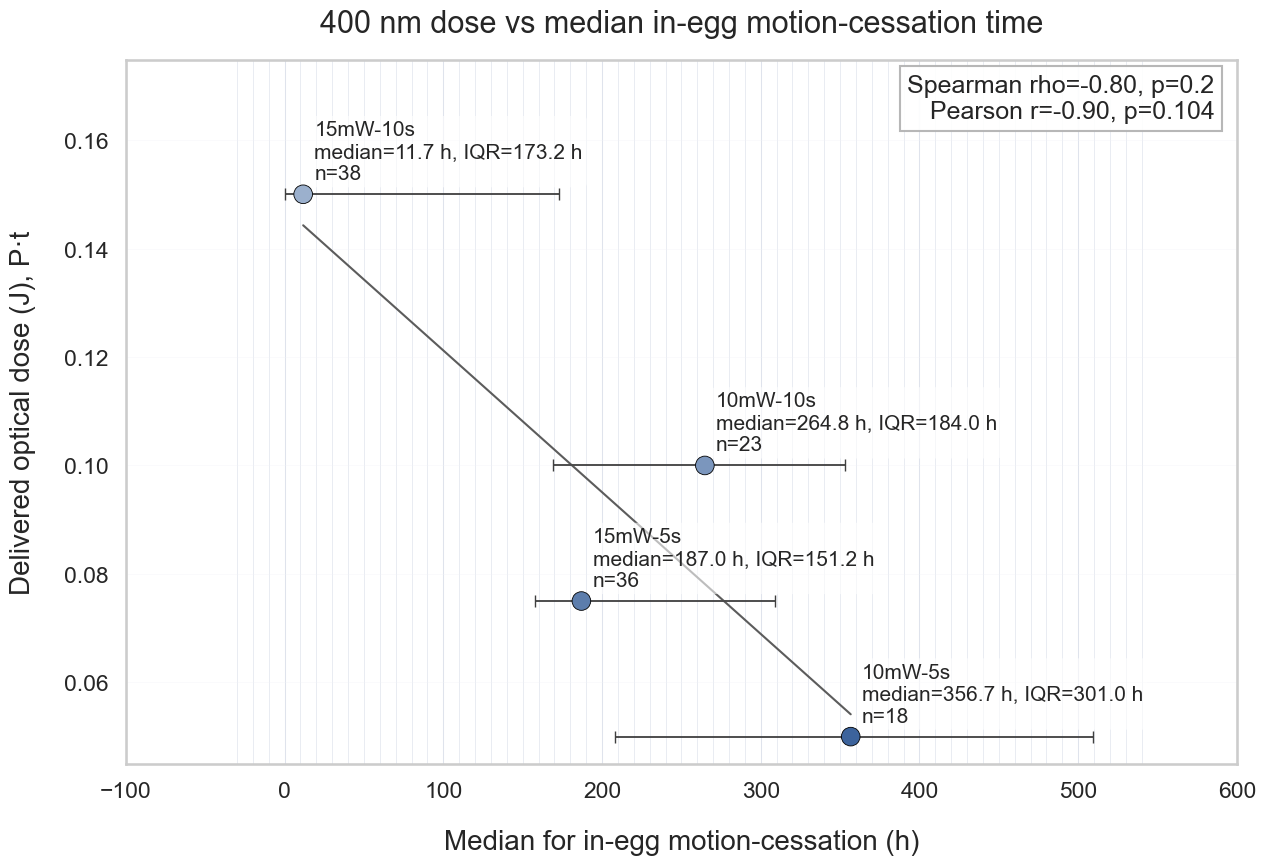

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/embryonated/plots/shg_embryonated_selected_10_15mW_fluence_median_iqr_outcomes.png
Figure caption: Relationship between delivered optical dose at 400 nm (J = P*t) and median in-egg motion-cessation time (h) for selected SHG treatments (10mW-5s, 10mW-10s, 15mW-5s, 15mW-10s). Each point is one treatment-level summary; horizontal whiskers show the interquartile range (Q1-Q3) around the median. Point labels report treatment, median, IQR, and n eggs with observed in-egg motion cessation. The gray line is an unweighted linear fit across treatment-level points and is shown as a descriptive trend only. Correlation summary: Spearman rho=-0.80 (p=0.2); Pearson r=-0.90 (p=0.104); n_groups=4. Interpretation note: this is a group-level analysis with a small number of groups, so p-values and confidence in significance should be interpreted cautiously.
Relation note: Spearman analysis indicates a moderate negative effect (rho=-0.80, p=

In [14]:
# Plot selected SHG fluence correlation results (medians only; IQR shown as whiskers)

if "shg_fluence_summary_df" not in globals() or shg_fluence_summary_df.empty:
    raise RuntimeError("Run Step 10 first to create `shg_fluence_summary_df` and `shg_fluence_correlation_df`.")

plot_df = (
    shg_fluence_summary_df
    .dropna(subset=["fluence_400nm_J", "median_dt_motion_stop_h", "q1_dt_motion_stop_h", "q3_dt_motion_stop_h"])
    .copy()
    .sort_values("fluence_400nm_J")
)
plot_df["treatment_short"] = plot_df["treatment"].str.replace("400-SHG-", "", regex=False)

if plot_df.empty:
    raise RuntimeError("No data available for plotting selected SHG fluence correlations.")

palette = sns.blend_palette(["#3c639c", "#9bb0cd"], n_colors=max(len(plot_df), 3))
point_colors = palette[: len(plot_df)]

fig, ax = plt.subplots(1, 1, figsize=(13, 9))

xerr_iqr = np.vstack([
    plot_df["median_dt_motion_stop_h"] - plot_df["q1_dt_motion_stop_h"],
    plot_df["q3_dt_motion_stop_h"] - plot_df["median_dt_motion_stop_h"],
])
ax.errorbar(
    plot_df["median_dt_motion_stop_h"],
    plot_df["fluence_400nm_J"],
    xerr=xerr_iqr,
    fmt="none",
    ecolor="#3f3f3f",
    elinewidth=1.3,
    capsize=4,
    zorder=1,
)
if plot_df.shape[0] >= 2:
    sns.regplot(
        data=plot_df,
        x="median_dt_motion_stop_h",
        y="fluence_400nm_J",
        scatter=False,
        ci=None,
        color="#4a4a4a",
        line_kws={"linewidth": 1.5, "alpha": 0.9},
        ax=ax,
    )

palette_map = dict(zip(plot_df["treatment_short"], point_colors))
sns.scatterplot(
    data=plot_df,
    x="median_dt_motion_stop_h",
    y="fluence_400nm_J",
    hue="treatment_short",
    palette=palette_map,
    s=180,
    edgecolor="black",
    linewidth=0.6,
    legend=False,
    ax=ax,
    zorder=3,
)

cur_bottom, cur_top = ax.get_ylim()
ax.set_ylim(cur_bottom, cur_top + max((cur_top - cur_bottom) * 0.18, 0.01))

x_min, x_max = ax.get_xlim()
x_min = float(np.floor(x_min))
x_max = float(np.ceil(x_max))
x_start = 10 * np.floor(x_min / 10.0)
x_end = 10 * np.ceil(x_max / 10.0)
if x_end <= x_start:
    x_end = x_start + 10
major_start = 100 * np.floor(x_min / 100.0)
major_end = 100 * np.ceil(x_max / 100.0)
if major_end <= major_start:
    major_end = major_start + 100
ax.set_xticks(np.arange(major_start, major_end + 100, 100))
ax.set_xticks(np.arange(x_start, x_end + 10, 10), minor=True)

for _, row in plot_df.iterrows():
    label = (
        f"{row['treatment_short']}\n"
        f"median={row['median_dt_motion_stop_h']:.1f} h, IQR={row['iqr_dt_motion_stop_h']:.1f} h\n"
        f"n={int(row['n_stopped_in_egg'])}"
    )
    xy_offset = (8, 8)
    va = "bottom"
    if row["treatment_short"] == "15mW-5s":
        xy_offset = (8, 8)
        va = "bottom"

    ax.annotate(
        label,
        (row["median_dt_motion_stop_h"], row["fluence_400nm_J"]),
        xytext=xy_offset,
        textcoords="offset points",
        fontsize=15,
        ha="left",
        va=va,
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2", alpha=0.6),
    )

corr_median = shg_fluence_correlation_df.loc[
    shg_fluence_correlation_df["metric"] == "median_dt_motion_stop_h"
]
if not corr_median.empty:
    cm = corr_median.iloc[0]
    txt = (
        f"Spearman rho={cm['spearman_rho']:.2f}, p={cm['spearman_p']:.3g}\n"
        f"Pearson r={cm['pearson_r']:.2f}, p={cm['pearson_p']:.3g}"
    )
    ax.text(
        0.98,
        0.98,
        txt,
        transform=ax.transAxes,
        fontsize=18,
        va="top",
        ha="right",
        bbox=dict(facecolor="white", edgecolor="#b0b0b0", boxstyle="square,pad=0.3", alpha=0.9),
    )

ax.set_title("400 nm dose vs median in-egg motion-cessation time", fontsize=22, pad=20)
ax.set_xlabel("Median for in-egg motion-cessation (h)", fontsize=20, labelpad=20)
ax.set_ylabel("Delivered optical dose (J), P·t", fontsize=20, labelpad=20)
ax.grid(False)
ax.grid(axis="x", which="minor", color="#e3e7ee", linewidth=0.6, alpha=0.9)
ax.grid(axis="x", which="major", color="#d7dde8", linewidth=0.75, alpha=0.8)
ax.grid(axis="y", which="major", color="#f0f2f6", linewidth=0.5, alpha=0.45)

plt.tight_layout()

out_png = PLOTS_DIR / "shg_embryonated_selected_10_15mW_fluence_median_iqr_outcomes.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")

if not corr_median.empty:
    corr_caption = (
        f"Spearman rho={cm['spearman_rho']:.2f} (p={cm['spearman_p']:.3g}); "
        f"Pearson r={cm['pearson_r']:.2f} (p={cm['pearson_p']:.3g}); "
        f"n_groups={int(cm['n_groups'])}"
    )
else:
    corr_caption = "Correlation metrics unavailable (insufficient non-missing points)."

figure_caption = (
    "Figure caption: Relationship between delivered optical dose at 400 nm (J = P*t) and "
    "median in-egg motion-cessation time (h) for selected SHG treatments "
    "(10mW-5s, 10mW-10s, 15mW-5s, 15mW-10s). "
    "Each point is one treatment-level summary; horizontal whiskers show the interquartile range "
    "(Q1-Q3) around the median. Point labels report treatment, median, IQR, and n eggs with "
    "observed in-egg motion cessation. The gray line is an unweighted linear fit across "
    "treatment-level points and is shown as a descriptive trend only. "
    f"Correlation summary: {corr_caption}. "
    "Interpretation note: this is a group-level analysis with a small number of groups, so "
    "p-values and confidence in significance should be interpreted cautiously."
)
print(figure_caption)

if not corr_median.empty:
    rho_val = cm["spearman_rho"]
    p_val = cm["spearman_p"]
    n_groups = int(cm["n_groups"]) if pd.notna(cm["n_groups"]) else np.nan
    if pd.notna(rho_val) and pd.notna(p_val):
        if rho_val > 0:
            direction = "positive"
        elif rho_val < 0:
            direction = "negative"
        else:
            direction = "no clear"

        abs_rho = abs(float(rho_val))
        if abs_rho >= 0.8:
            strength = "strong"
        elif abs_rho >= 0.5:
            strength = "moderate"
        elif abs_rho >= 0.3:
            strength = "weak-to-moderate"
        else:
            strength = "weak"

        if p_val <= 0.05:
            significance_note = "statistically significant"
        else:
            significance_note = "not statistically significant; interpret as a tendency/trend"

        print(
            "Relation note: "
            f"Spearman analysis indicates a {strength} {direction} effect "
            f"(rho={rho_val:.2f}, p={p_val:.3g}, n_groups={n_groups}); "
            f"this relation is {significance_note}."
        )
    else:
        print("Relation note: Effect direction/strength unavailable because Spearman outputs are missing.")
else:
    print("Relation note: Effect and significance unavailable because no median-correlation row was found.")
